# Logistic Regression Comparison Models

Here we compare regularized logistic regression against the random-choice baseline for all three binary classification tasks:
- Healthy vs infected
- Symptomatic non-COVID vs COVID
- Severe vs non-severe COVID


## 1. Load libraries and task folders

Read the task-specific train/test matrices, labels, metadata, and selected peptide feature lists created in `preprocessing.ipynb`.


In [8]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.exceptions import ConvergenceWarning
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore", category=ConvergenceWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 100)

In [9]:
PROCESSED_DIR = Path("data/processed")
TASK_NAMES = [
    "healthy_vs_infected",
    "symptomatic_non_covid_vs_covid",
    "severe_vs_nonsevere",
]

task_data = {}

for task_name in TASK_NAMES:
    task_dir = PROCESSED_DIR / task_name
    task_data[task_name] = {
        "dir": task_dir,
        "X_train": pd.read_csv(task_dir / "X_train_scaled.csv", index_col=0),
        "X_test": pd.read_csv(task_dir / "X_test_scaled.csv", index_col=0),
        "y_train": pd.read_csv(task_dir / "y_train.csv", index_col=0).squeeze("columns"),
        "y_test": pd.read_csv(task_dir / "y_test.csv", index_col=0).squeeze("columns"),
        "metadata_train": pd.read_csv(task_dir / "metadata_train.csv", index_col=0),
        "metadata_test": pd.read_csv(task_dir / "metadata_test.csv", index_col=0),
        "selected_peptides": pd.read_csv(task_dir / "selected_peptides.csv"),
    }

    print(f"\n{task_name}")
    print(f"X_train shape: {task_data[task_name]['X_train'].shape}")
    print(f"X_test shape: {task_data[task_name]['X_test'].shape}")
    print("Train label counts:")
    print(task_data[task_name]["metadata_train"]["label_name"].value_counts())
    print("Test label counts:")
    print(task_data[task_name]["metadata_test"]["label_name"].value_counts())



healthy_vs_infected
X_train shape: (72, 35882)
X_test shape: (18, 35882)
Train label counts:
label_name
Infected    54
Healthy     18
Name: count, dtype: int64
Test label counts:
label_name
Infected    14
Healthy      4
Name: count, dtype: int64

symptomatic_non_covid_vs_covid
X_train shape: (54, 35882)
X_test shape: (14, 35882)
Train label counts:
label_name
COVID-19                    34
Symptomatic-non-COVID-19    20
Name: count, dtype: int64
Test label counts:
label_name
COVID-19                    9
Symptomatic-non-COVID-19    5
Name: count, dtype: int64

severe_vs_nonsevere
X_train shape: (34, 35882)
X_test shape: (9, 35882)
Train label counts:
label_name
Non-severe-COVID-19    20
Severe-COVID-19        14
Name: count, dtype: int64
Test label counts:
label_name
Non-severe-COVID-19    5
Severe-COVID-19        4
Name: count, dtype: int64


## 2. Define evaluation helpers

Use stratified cross-validation on the training set and evaluate the final fitted model on the held-out test set. Feature pre-selection is included inside the pipeline to reduce overfitting and keep the comparison computationally practical.


In [10]:
TOP_K_FEATURES = 5000  # Set to a large number to include all features; can change if needed

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)


def make_pipeline(logistic_model, n_features):
    return Pipeline([
        ("select", SelectKBest(score_func=f_classif, k=min(TOP_K_FEATURES, n_features))),
        ("model", logistic_model),
    ])


def safe_roc_auc(y_true, y_score):
    if pd.Series(y_true).nunique() < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)


def safe_auprc(y_true, y_score):
    if pd.Series(y_true).nunique() < 2:
        return np.nan
    return average_precision_score(y_true, y_score)


def build_logistic_model(spec):
    return LogisticRegression(
        penalty=spec["penalty"],
        C=spec["C"],
        l1_ratio=spec["l1_ratio"],
        solver=spec["solver"],
        max_iter=spec["max_iter"],
        tol=spec["tol"],
        class_weight="balanced",
        random_state=42,
    )


def evaluate_model_nested(task_name, data, spec):
    X_train = data["X_train"]
    X_test = data["X_test"]
    y_train = data["y_train"]
    y_test = data["y_test"]

    outer_scores = []
    n_features = X_train.shape[1]

    for fold_idx, (train_idx, val_idx) in enumerate(outer_cv.split(X_train, y_train)):
        X_outer_train = X_train.iloc[train_idx]
        X_outer_val = X_train.iloc[val_idx]
        y_outer_train = y_train.iloc[train_idx]
        y_outer_val = y_train.iloc[val_idx]

        base_pipeline = make_pipeline(build_logistic_model(spec), n_features)

        # Inner loop exists for structural parity with the other models.
        # For a fixed spec, this selects the same configuration through inner CV.
        grid = GridSearchCV(
            estimator=base_pipeline,
            param_grid={"model__C": [spec["C"]]},
            cv=inner_cv,
            scoring="balanced_accuracy",
            n_jobs=-1,
            error_score=np.nan,
        )
        grid.fit(X_outer_train, y_outer_train)

        best_pipeline = grid.best_estimator_
        y_pred = best_pipeline.predict(X_outer_val)
        y_proba = best_pipeline.predict_proba(X_outer_val)[:, 1]

        outer_scores.append({
            "fold": fold_idx,
            "val_accuracy": accuracy_score(y_outer_val, y_pred),
            "val_balanced_accuracy": balanced_accuracy_score(y_outer_val, y_pred),
            "val_f1": f1_score(y_outer_val, y_pred, zero_division=0),
            "val_roc_auc": safe_roc_auc(y_outer_val, y_proba),
            "val_auprc": safe_auprc(y_outer_val, y_proba),
        })

    final_pipeline = make_pipeline(build_logistic_model(spec), n_features)
    final_pipeline.fit(X_train, y_train)
    y_test_pred = final_pipeline.predict(X_test)
    y_test_proba = final_pipeline.predict_proba(X_test)[:, 1]
    fitted_model = final_pipeline.named_steps["model"]

    return {
        "task": task_name,
        "model": spec["model_name"],
        "penalty": spec["penalty"],
        "C": spec["C"],
        "l1_ratio": spec["l1_ratio"],
        "top_k_features": min(TOP_K_FEATURES, X_train.shape[1]),
        "train_samples": X_train.shape[0],
        "test_samples": X_test.shape[0],
        "features": X_train.shape[1],
        "cv_accuracy_mean": float(np.mean([r["val_accuracy"] for r in outer_scores])),
        "cv_balanced_accuracy_mean": float(np.mean([r["val_balanced_accuracy"] for r in outer_scores])),
        "cv_f1_mean": float(np.mean([r["val_f1"] for r in outer_scores])),
        "cv_roc_auc_mean": float(np.mean([r["val_roc_auc"] for r in outer_scores])),
        "cv_auprc_mean": float(np.mean([r["val_auprc"] for r in outer_scores])),
        "test_accuracy": accuracy_score(y_test, y_test_pred),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, y_test_pred),
        "test_precision": precision_score(y_test, y_test_pred, zero_division=0),
        "test_recall": recall_score(y_test, y_test_pred, zero_division=0),
        "test_f1": f1_score(y_test, y_test_pred, zero_division=0),
        "test_roc_auc": safe_roc_auc(y_test, y_test_proba),
        "test_auprc": safe_auprc(y_test, y_test_proba),
        "nonzero_coefficients": int(np.count_nonzero(fitted_model.coef_)),
    }

## 3. Model specifications

Compare the standard L2 logistic regression baseline with L2, L1, and Elastic Net regularization across a compact set of `C` values.


In [11]:
model_specs = [
    {
        "model_name": "normal_default_l2_C=1",
        "penalty": "l2",
        "C": 1.0,
        "l1_ratio": None,
        "solver": "liblinear",
        "max_iter": 5000,
        "tol": 1e-4,
    },
]

for C in [0.01, 0.1, 10]:
    model_specs.append({
        "model_name": f"l2_C={C}",
        "penalty": "l2",
        "C": C,
        "l1_ratio": None,
        "solver": "liblinear",
        "max_iter": 3000,
        "tol": 1e-3,
    })

for C in [0.01, 0.1, 1, 10]:
    model_specs.append({
        "model_name": f"l1_C={C}",
        "penalty": "l1",
        "C": C,
        "l1_ratio": None,
        "solver": "liblinear",
        "max_iter": 3000,
        "tol": 1e-3,
    })

for C in [0.1, 1]:
    model_specs.append({
        "model_name": f"elasticnet_C={C}_l1_ratio=0.5",
        "penalty": "elasticnet",
        "C": C,
        "l1_ratio": 0.5,
        "solver": "saga",
        "max_iter": 3000,
        "tol": 1e-3,
    })

len(model_specs)


10

## 4. Run all task comparisons

In [12]:
all_results = []

for task_name, data in task_data.items():
    print(f"Running {task_name}...")
    for spec in model_specs:
        all_results.append(evaluate_model_nested(
            task_name=task_name,
            data=data,
            spec=spec,
        ))

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(
    by=["task", "cv_balanced_accuracy_mean", "cv_f1_mean"],
    ascending=[True, False, False],
).reset_index(drop=True)

results_df

Running healthy_vs_infected...


c:\Users\yufam\Workspace\cse291\cse291-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\yufam\Workspace\cse291\cse291-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l2 with l1_ratio=None. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\yufam\Workspace\cse291\cse291-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2',

Running symptomatic_non_covid_vs_covid...


c:\Users\yufam\Workspace\cse291\cse291-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\yufam\Workspace\cse291\cse291-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l2 with l1_ratio=None. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\yufam\Workspace\cse291\cse291-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2',

Running severe_vs_nonsevere...


c:\Users\yufam\Workspace\cse291\cse291-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\yufam\Workspace\cse291\cse291-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l2 with l1_ratio=None. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\yufam\Workspace\cse291\cse291-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2',

,task,model,penalty,C,l1_ratio,top_k_features,train_samples,test_samples,features,cv_accuracy_mean,cv_balanced_accuracy_mean,cv_f1_mean,cv_roc_auc_mean,cv_auprc_mean,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_auprc,nonzero_coefficients
0,healthy_vs_infected,l1_C=1,l1,1.00,NaN,5000,72,18,35882,0.944762,0.945909,0.959596,0.962727,0.987862,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,67
1,healthy_vs_infected,l1_C=10,l1,10.00,NaN,5000,72,18,35882,0.944762,0.930909,0.961818,0.967273,0.989680,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,200
2,healthy_vs_infected,elasticnet_C=0.1_l1_ratio=0.5,elasticnet,0.10,0.5,5000,72,18,35882,0.917143,0.927727,0.939683,0.968182,0.989660,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,64
3,healthy_vs_infected,l1_C=0.1,l1,0.10,NaN,5000,72,18,35882,0.890476,0.901212,0.915114,0.959697,0.986492,0.944444,0.964286,1.000000,0.928571,0.962963,0.982143,0.995238,4
4,healthy_vs_infected,elasticnet_C=1_l1_ratio=0.5,elasticnet,1.00,0.5,5000,72,18,35882,0.848571,0.897273,0.880261,0.962727,0.987862,0.944444,0.964286,1.000000,0.928571,0.962963,1.000000,1.000000,799
5,healthy_vs_infected,normal_default_l2_C=1,l2,1.00,NaN,5000,72,18,35882,0.793333,0.860000,0.829532,0.924545,0.973841,0.777778,0.857143,1.000000,0.714286,0.833333,0.982143,0.995238,5000
6,healthy_vs_infected,l2_C=0.1,l2,0.10,NaN,5000,72,18,35882,0.765714,0.841818,0.802288,0.920455,0.972718,0.777778,0.857143,1.000000,0.714286,0.833333,0.982143,0.995238,5000
7,healthy_vs_infected,l2_C=10,l2,10.00,NaN,5000,72,18,35882,0.764762,0.841818,0.802288,0.929545,0.975124,0.777778,0.857143,1.000000,0.714286,0.833333,0.982143,0.995238,5000
8,healthy_vs_infected,l2_C=0.01,l2,0.01,NaN,5000,72,18,35882,0.764762,0.840909,0.798486,0.930000,0.976458,0.777778,0.857143,1.000000,0.714286,0.833333,0.982143,0.995238,5000
9,healthy_vs_infected,l1_C=0.01,l1,0.01,NaN,5000,72,18,35882,0.249524,0.500000,0.000000,0.500000,0.750476,0.222222,0.500000,0.000000,0.000000,0.000000,0.500000,0.777778,0


## 5. Save results and per-task plots


Saved combined results table to: C:\Users\yufam\Workspace\cse291\cse291-project\data\processed\logistic_regression_baseline_results_all_tasks.csv


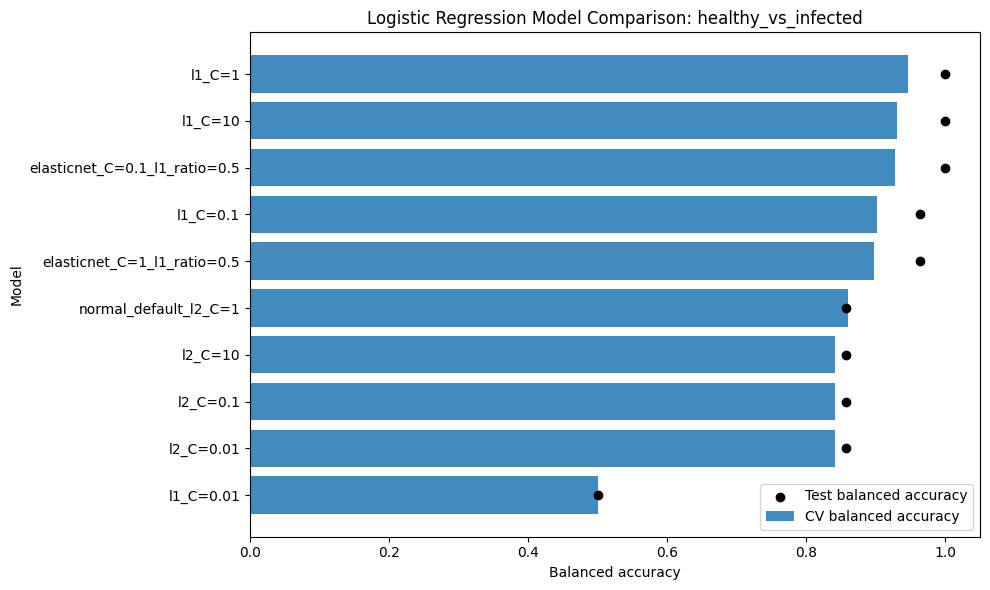

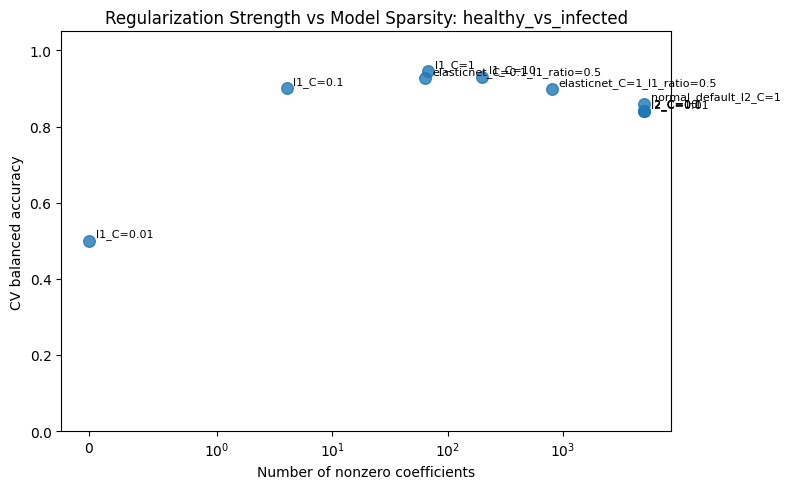

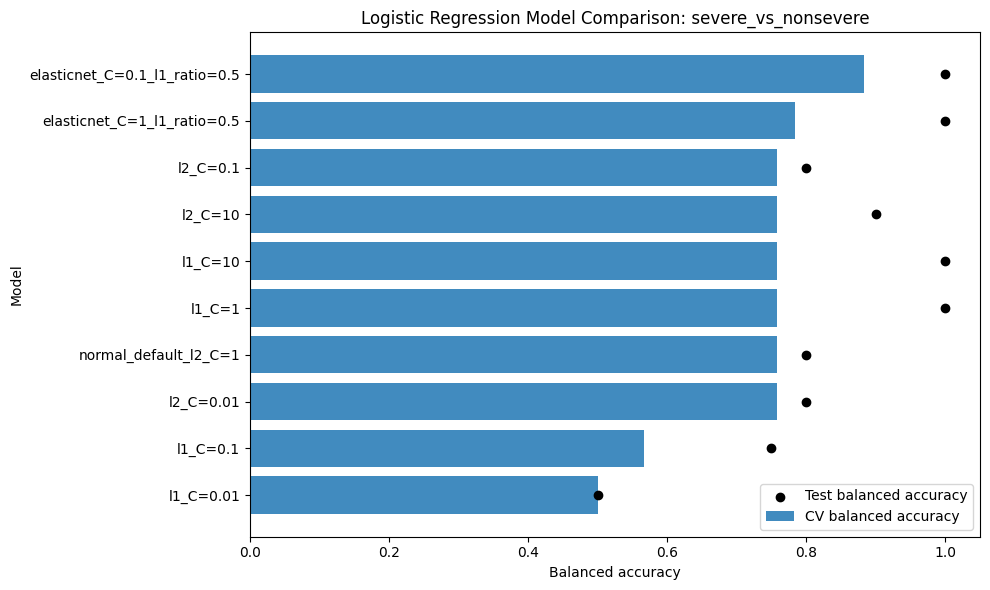

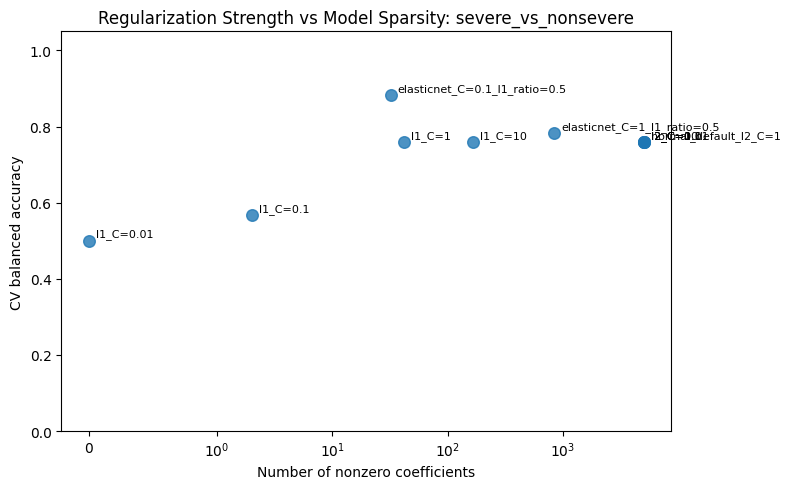

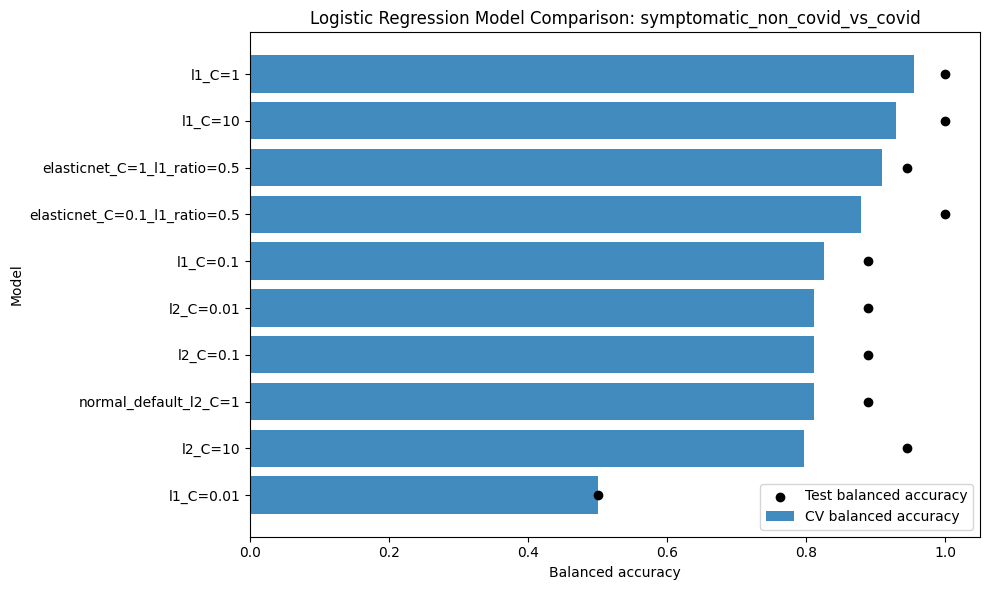

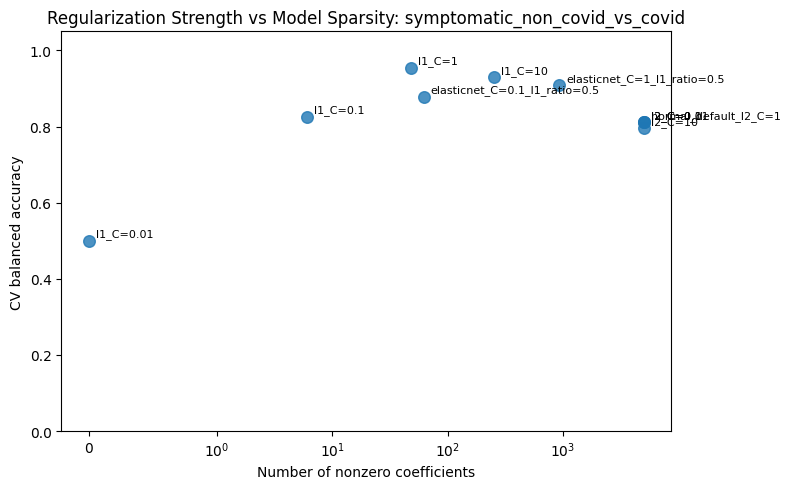

In [13]:
results_path = PROCESSED_DIR / "logistic_regression_baseline_results_all_tasks.csv"
results_df.to_csv(results_path, index=False)
print(f"Saved combined results table to: {results_path.resolve()}")

for task_name, task_results in results_df.groupby("task", sort=False):
    task_dir = PROCESSED_DIR / task_name
    task_results = task_results.sort_values(
        by=["cv_balanced_accuracy_mean", "cv_f1_mean"],
        ascending=False,
    ).reset_index(drop=True)
    task_results.to_csv(task_dir / "logistic_regression_baseline_results.csv", index=False)

    plot_df = task_results.sort_values("cv_balanced_accuracy_mean", ascending=True).copy()
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(
        plot_df["model"],
        plot_df["cv_balanced_accuracy_mean"],
        label="CV balanced accuracy",
        alpha=0.85,
    )
    ax.scatter(
        plot_df["test_balanced_accuracy"],
        plot_df["model"],
        color="black",
        label="Test balanced accuracy",
        zorder=3,
    )
    ax.set_xlabel("Balanced accuracy")
    ax.set_ylabel("Model")
    ax.set_xlim(0, 1.05)
    ax.set_title(f"Logistic Regression Model Comparison: {task_name}")
    ax.legend(loc="lower right")
    plt.tight_layout()
    fig.savefig(task_dir / "logistic_regression_balanced_accuracy.png", dpi=300, bbox_inches="tight", facecolor="white", edgecolor="white")
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(
        task_results["nonzero_coefficients"],
        task_results["cv_balanced_accuracy_mean"],
        s=70,
        alpha=0.8,
    )
    for _, row in task_results.iterrows():
        ax.annotate(
            row["model"],
            (row["nonzero_coefficients"], row["cv_balanced_accuracy_mean"]),
            xytext=(5, 3),
            textcoords="offset points",
            fontsize=8,
        )
    ax.set_xlabel("Number of nonzero coefficients")
    ax.set_ylabel("CV balanced accuracy")
    ax.set_title(f"Regularization Strength vs Model Sparsity: {task_name}")
    ax.set_xscale("symlog", linthresh=1)
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    fig.savefig(task_dir / "logistic_regression_sparsity_vs_accuracy.png", dpi=300, bbox_inches="tight", facecolor="white", edgecolor="white")
    plt.show()

## 6. Inspect best coefficients for each task

For interpretability, refit the top model for each task and save the peptide features with the largest absolute coefficients.


c:\Users\yufam\Workspace\cse291\cse291-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\yufam\Workspace\cse291\cse291-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=None. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


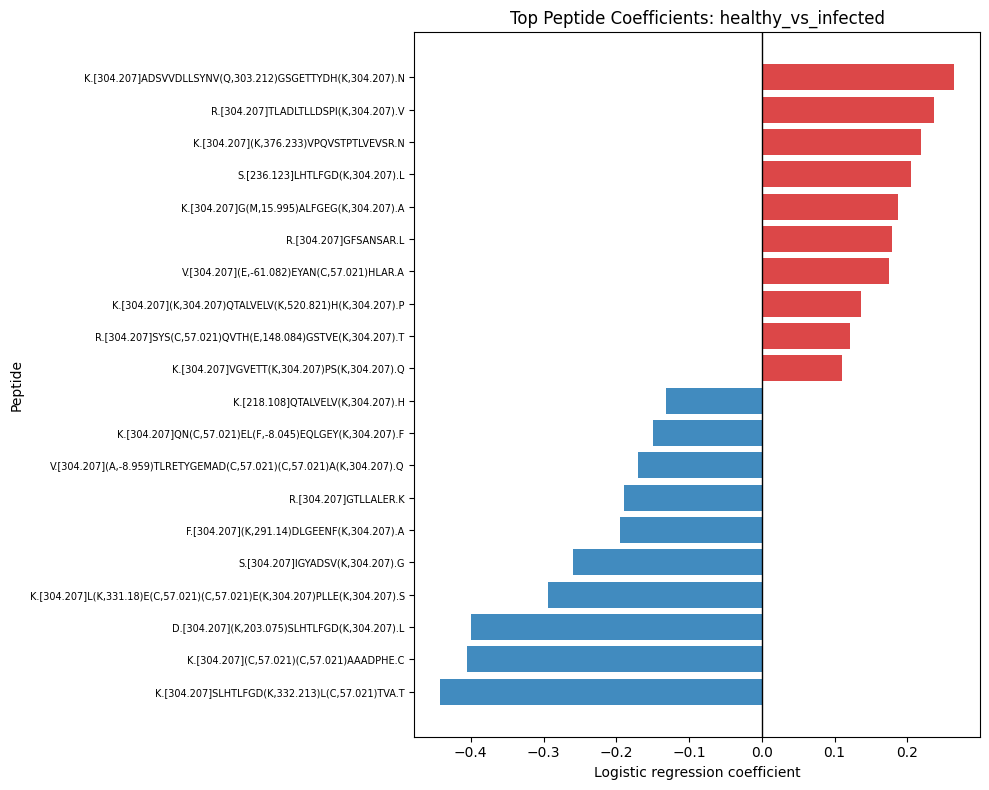

c:\Users\yufam\Workspace\cse291\cse291-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\yufam\Workspace\cse291\cse291-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=None. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


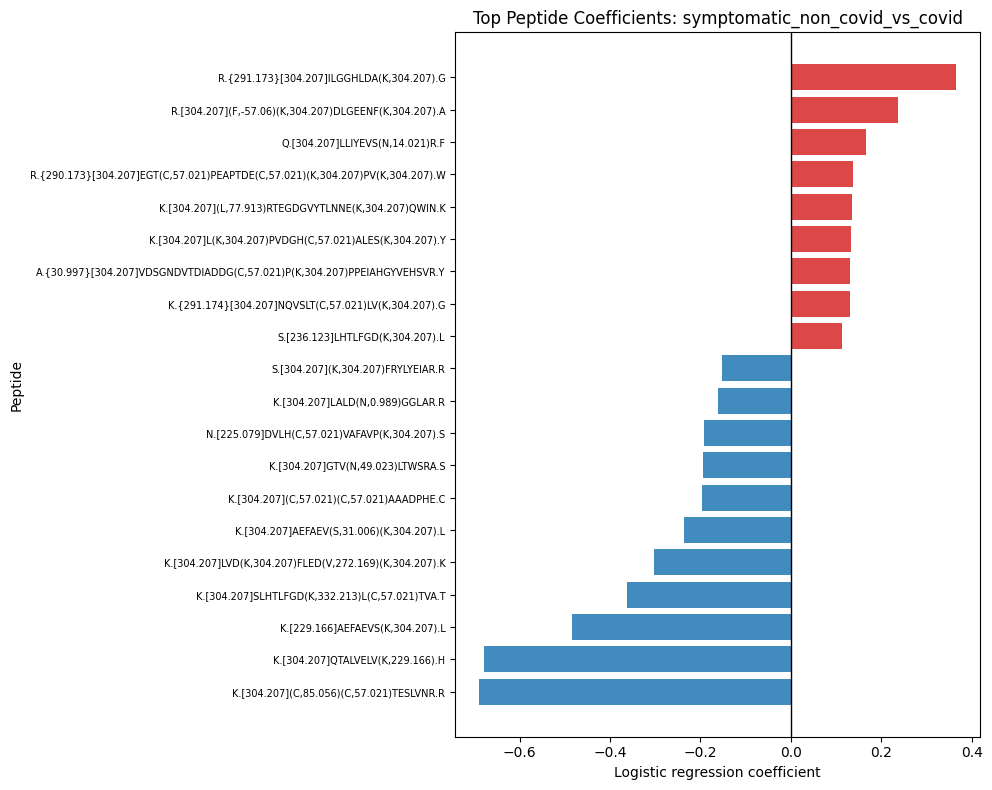

c:\Users\yufam\Workspace\cse291\cse291-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


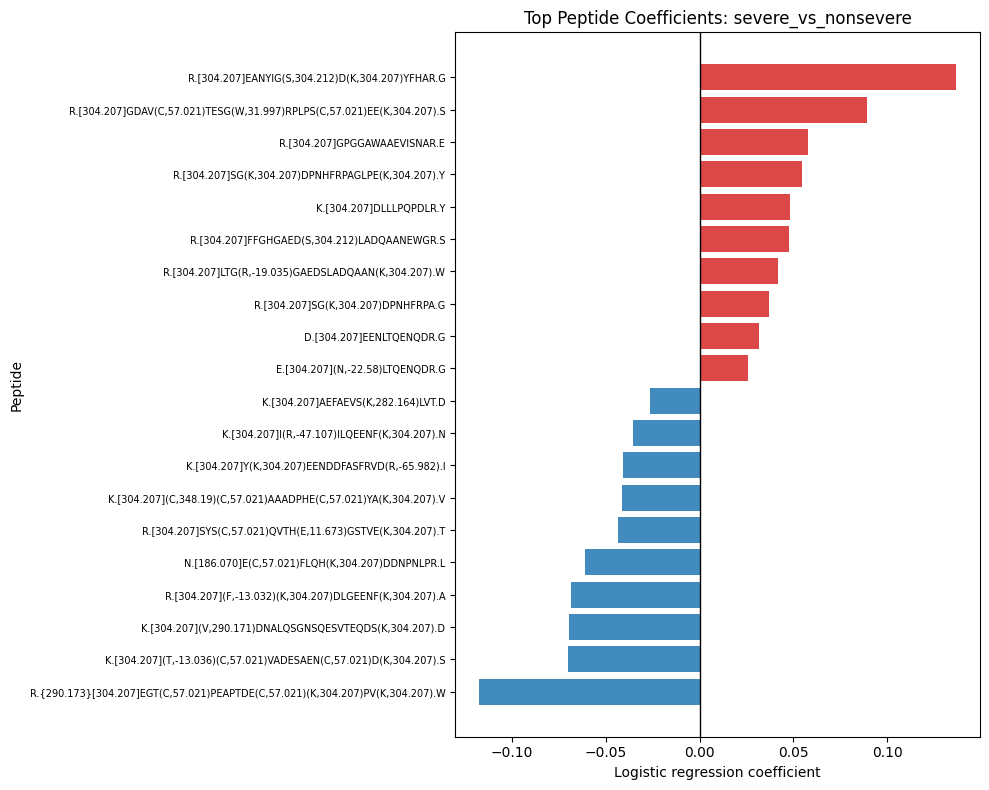

,task,model,penalty,C,l1_ratio,top_k_features,train_samples,test_samples,features,cv_accuracy_mean,cv_balanced_accuracy_mean,cv_f1_mean,cv_roc_auc_mean,cv_auprc_mean,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_auprc,nonzero_coefficients
0,healthy_vs_infected,l1_C=1,l1,1.0,NaN,5000,72,18,35882,0.944762,0.945909,0.959596,0.962727,0.987862,1.0,1.0,1.0,1.0,1.0,1.0,1.0,67
1,symptomatic_non_covid_vs_covid,l1_C=1,l1,1.0,NaN,5000,54,14,35882,0.943636,0.954762,0.948485,0.985714,0.993651,1.0,1.0,1.0,1.0,1.0,1.0,1.0,48
2,severe_vs_nonsevere,elasticnet_C=0.1_l1_ratio=0.5,elasticnet,0.1,0.5,5000,34,9,35882,0.885714,0.883333,0.862857,0.950000,0.956667,1.0,1.0,1.0,1.0,1.0,1.0,1.0,32


In [14]:
def build_model_from_results(row, n_features):
    solver = "saga" if row["penalty"] == "elasticnet" else "liblinear"
    logistic_model = LogisticRegression(
        penalty=row["penalty"],
        C=row["C"],
        l1_ratio=None if pd.isna(row["l1_ratio"]) else row["l1_ratio"],
        solver=solver,
        max_iter=3000,
        tol=1e-3,
        class_weight="balanced",
        random_state=42,
    )
    return make_pipeline(logistic_model, n_features)


best_rows = []
coef_tables = {}

for task_name, data in task_data.items():
    task_results = results_df[results_df["task"].eq(task_name)].sort_values(
        by=["cv_balanced_accuracy_mean", "cv_f1_mean"],
        ascending=False,
    ).reset_index(drop=True)
    best_row = task_results.iloc[0]
    best_rows.append(best_row)

    best_pipeline = build_model_from_results(best_row, data["X_train"].shape[1])
    best_pipeline.fit(data["X_train"], data["y_train"])

    selector = best_pipeline.named_steps["select"]
    best_model = best_pipeline.named_steps["model"]
    selected_feature_names = data["X_train"].columns[selector.get_support()]

    coef_df = pd.DataFrame({
        "task": task_name,
        "peptide": selected_feature_names,
        "coefficient": best_model.coef_.ravel(),
    })
    coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
    coef_df = coef_df.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)
    coef_tables[task_name] = coef_df

    task_dir = data["dir"]
    coef_df.to_csv(task_dir / "logistic_regression_top_coefficients.csv", index=False)

    top_coef_plot_df = coef_df.head(20).sort_values("coefficient")
    colors = np.where(top_coef_plot_df["coefficient"] >= 0, "tab:red", "tab:blue")
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(top_coef_plot_df["peptide"], top_coef_plot_df["coefficient"], color=colors, alpha=0.85)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlabel("Logistic regression coefficient")
    ax.set_ylabel("Peptide")
    ax.set_title(f"Top Peptide Coefficients: {task_name}")
    ax.tick_params(axis="y", labelsize=7)
    plt.tight_layout()
    fig.savefig(task_dir / "logistic_regression_top_coefficients.png", dpi=300, bbox_inches="tight", facecolor="white", edgecolor="white")
    plt.show()

best_models_df = pd.DataFrame(best_rows).reset_index(drop=True)
best_models_df.to_csv(PROCESSED_DIR / "logistic_regression_best_models_by_task.csv", index=False)
best_models_df